100%|██████████| 20000/20000 [00:18<00:00, 1076.95it/s]


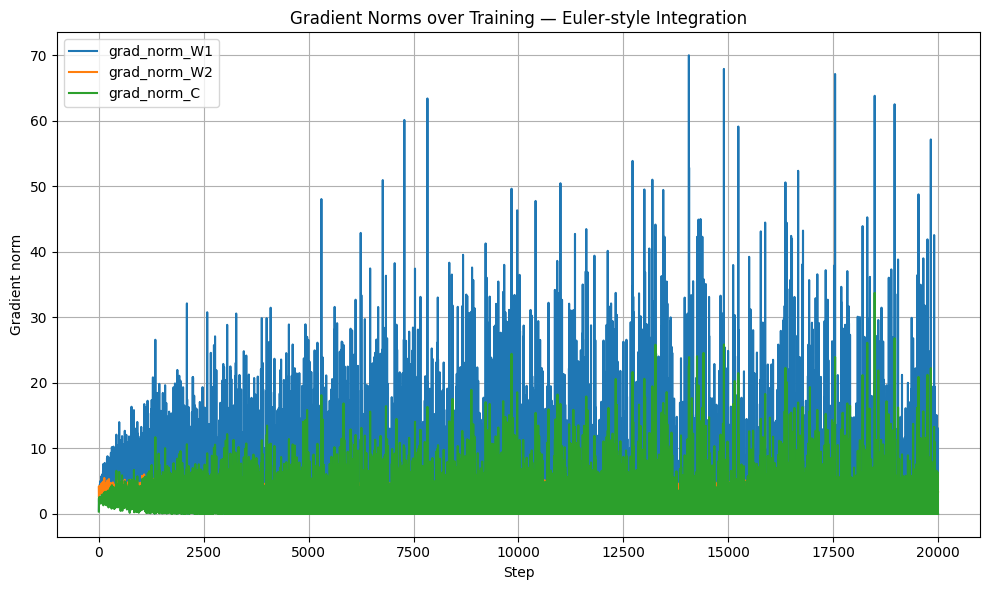

In [4]:
# gradient_time_series.py

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import trange

# ——————————————————————————————————————————
# Load dataset (names) and build bigram dataset
words = open('/home/maria/andrej-karpathy-experiments/names.txt','r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

xs, ys = [], []
block_size = 3
for w in words:
    chs = ['.'] + list(w) + ['.']
    for k in range(len(chs)-block_size):
        context = chs[k:k+block_size]
        target = chs[k+block_size]
        xs.append([stoi[c] for c in context])
        ys.append(stoi[target])

X = torch.tensor(xs)
Y = torch.tensor(ys)
n_examples, seq_len = X.shape
device = 'cpu'

# ——————————————————————————————————————————
# Model initialization
n_embd = 10
n_hidden = 200
vocab_size = len(stoi)

# Model initialization — FIXED
C = torch.randn(vocab_size, n_embd, generator=g, device=device)
W1 = torch.randn(n_embd*block_size, n_hidden, generator=g, device=device)
b1 = torch.randn(n_hidden, generator=g, device=device)
W2 = torch.randn(n_hidden, vocab_size, generator=g, device=device) * 0.1
b2 = torch.zeros(vocab_size, device=device)

# Wrap as leaf variables with requires_grad=True
parameters = [C, W1, b1, W2, b2]
parameters = [p.clone().detach().requires_grad_(True) for p in parameters]
C, W1, b1, W2, b2 = parameters


# ——————————————————————————————————————————
# Set up logging
steps = 20000
batch_size = 32
lr = 3.0

logs = {
    'grad_norm_W1': [],
    'grad_norm_W2': [],
    'grad_norm_C': [],
}

# ——————————————————————————————————————————
# Training loop
for step in trange(steps):
    idx = torch.randint(0, n_examples, (batch_size,), generator=g, device=device)
    Xb, Yb = X[idx], Y[idx]

    # Forward pass
    emb = C[Xb]                           # (B, block_size, n_embd)
    embcat = emb.view(batch_size, -1)    # (B, block_size * n_embd)
    hpre = embcat @ W1 + b1              # hidden pre-activation
    h = torch.tanh(hpre)                 # hidden activation
    logits = h @ W2 + b2                 # output logits
    loss = F.cross_entropy(logits, Yb)

    # Backward
    for p in parameters:
        if p.grad is not None:
            p.grad.zero_()
    loss.backward()

    # Log gradient norms
    logs['grad_norm_W1'].append(W1.grad.norm().item())
    logs['grad_norm_W2'].append(W2.grad.norm().item())
    logs['grad_norm_C'].append(C.grad.norm().item())

    # Euler-like update (GD step)
    for p in parameters:
        p.data -= lr * p.grad

# ——————————————————————————————————————————
# Plot the trajectories
plt.figure(figsize=(10,6))
for k, v in logs.items():
    plt.plot(v, label=k)
plt.xlabel('Step')
plt.ylabel('Gradient norm')
plt.title('Gradient Norms over Training — Euler‑style Integration')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
